In [1]:
!pip install nltk scikit-learn pandas numpy matplotlib seaborn scipy

In [2]:
import nltk
nltk.download('stopwords')
nltk.download('punkt')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.


True

In [3]:
!wget https://raw.githubusercontent.com/thiagorainmaker77/liar_dataset/master/train.tsv
!wget https://raw.githubusercontent.com/thiagorainmaker77/liar_dataset/master/test.tsv
!wget https://raw.githubusercontent.com/thiagorainmaker77/liar_dataset/master/valid.tsv

print("Dataset downloaded successfully!")

--2026-06-05 05:28:36--  https://raw.githubusercontent.com/thiagorainmaker77/liar_dataset/master/train.tsv
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 2408165 (2.3M) [text/plain]
Saving to: ‘train.tsv’

train.tsv           100%[===================>]   2.30M  --.-KB/s    in 0.07s   

2026-06-05 05:28:36 (31.9 MB/s) - ‘train.tsv’ saved [2408165/2408165]

--2026-06-05 05:28:36--  https://raw.githubusercontent.com/thiagorainmaker77/liar_dataset/master/test.tsv
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 301118 (294K) [text/pla

In [4]:
import pandas as pd

COLS = ['id','label','statement','subject','speaker','job','state','party',
        'barely_true','false','half_true','mostly_true','pants_fire','context']

train = pd.read_csv('train.tsv', sep='\t', header=None, names=COLS)
test  = pd.read_csv('test.tsv',  sep='\t', header=None, names=COLS)

print("Train size:", train.shape)
print("Test size:", test.shape)
print("\nLabel counts:\n", train['label'].value_counts())

Train size: (10240, 14)
Test size: (1267, 14)

Label counts:
 label
half-true      2114
false          1995
mostly-true    1962
true           1676
barely-true    1654
pants-fire      839
Name: count, dtype: int64


In [5]:
import re
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer

stop_words = set(stopwords.words('english'))
stemmer = PorterStemmer()

def binarize(label):
    return 0 if label in ['false', 'pants-fire', 'barely-true'] else 1

def clean_text(text):
    text = str(text).lower()
    text = re.sub(r'[^a-z\s]', '', text)
    tokens = [stemmer.stem(t) for t in text.split() if t not in stop_words]
    return ' '.join(tokens)

# Apply to both train and test
train['binary_label'] = train['label'].apply(binarize)
test['binary_label']  = test['label'].apply(binarize)

train['clean'] = train['statement'].apply(clean_text)
test['clean']  = test['statement'].apply(clean_text)

print("Preprocessing done!")
print(train[['statement', 'clean', 'binary_label']].head(3))

Preprocessing done!
                                           statement  \
0  Says the Annies List political group supports ...   
1  When did the decline of coal start? It started...   
2  Hillary Clinton agrees with John McCain "by vo...   

                                               clean  binary_label  
0  say anni list polit group support thirdtrimest...             0  
1  declin coal start start natur ga took start be...             1  
2  hillari clinton agre john mccain vote give geo...             1  


In [6]:
from sklearn.feature_extraction.text import TfidfVectorizer
from scipy.sparse import hstack, csr_matrix

NUM_COLS = ['barely_true', 'false', 'half_true', 'mostly_true', 'pants_fire']

# TF-IDF on text
tfidf = TfidfVectorizer(max_features=10000, ngram_range=(1, 2))
X_train = tfidf.fit_transform(train['clean'])
X_test  = tfidf.transform(test['clean'])

# Add speaker history features
num_train = csr_matrix(train[NUM_COLS].fillna(0).values)
num_test  = csr_matrix(test[NUM_COLS].fillna(0).values)

X_train = hstack([X_train, num_train])
X_test  = hstack([X_test,  num_test])

y_train = train['binary_label']
y_test  = test['binary_label']

print("Vectorization done!")
print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)

Vectorization done!
X_train shape: (10240, 10005)
X_test shape: (1267, 10005)


In [7]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=1000, C=1.0)
model.fit(X_train, y_train)

print("Model training done! ✅")

Model training done! ✅


Accuracy: 0.6251

               precision    recall  f1-score   support

        Fake       0.60      0.42      0.49       553
        Real       0.64      0.78      0.70       714

    accuracy                           0.63      1267
   macro avg       0.62      0.60      0.60      1267
weighted avg       0.62      0.63      0.61      1267



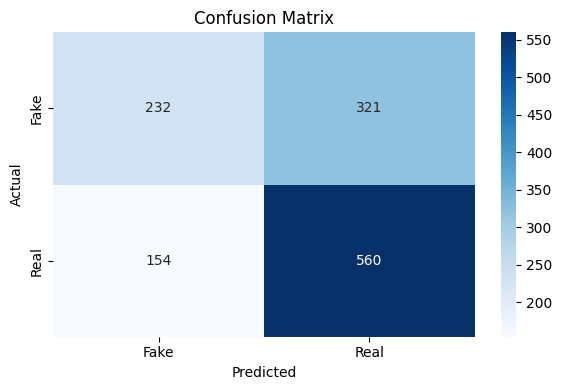

Confusion matrix saved!


In [8]:
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import matplotlib.pyplot as plt
import seaborn as sns

y_pred = model.predict(X_test)

print(f"Accuracy: {accuracy_score(y_test, y_pred):.4f}")
print("\n", classification_report(y_test, y_pred, target_names=['Fake', 'Real']))

cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Fake', 'Real'],
            yticklabels=['Fake', 'Real'])
plt.title('Confusion Matrix')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.savefig('confusion_matrix.png')
plt.show()
print("Confusion matrix saved!")